# Analyse de données des notes de film Senscritique

## Exploration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import string

In [2]:
films = pd.read_csv("../data/processed/films.csv")
ratings = pd.read_csv("../data/processed/all_ratings.csv")

ratings = ratings.rename(columns={'product_id': 'film_id'})
films   = films.rename(columns={'product_id': 'film_id'})

In [3]:
print("Forme de rating : ", ratings.shape)
print("Forme de films : ", films.shape)
ratings.head()

Forme de rating :  (47552698, 3)
Forme de films :  (5338, 2)


,film_id,user_id,rating
0,458754,2463805,10
1,458754,2384615,10
2,458754,2452401,7
3,458754,2462904,8
4,458754,2152577,8


In [4]:
print("Nombre d'utilisateurs uniques : ", ratings['user_id'].nunique())
print("Nombre de films uniques : ", ratings['film_id'].nunique())
print("Nombre total de notes : ", ratings.shape[0])


n_users = ratings['user_id'].nunique()
n_films = ratings['film_id'].nunique()
sparsity = 1 - len(ratings) / (n_users * n_films)

print("Sparsité du dataset : ", sparsity)

Nombre d'utilisateurs uniques :  582329
Nombre de films uniques :  5336
Nombre total de notes :  47552698
Sparsité du dataset :  0.9846964945288982


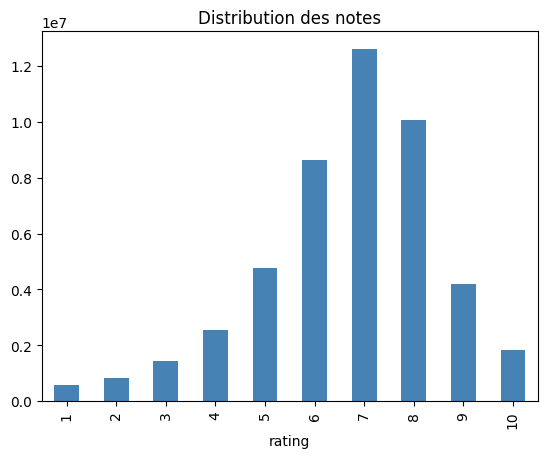

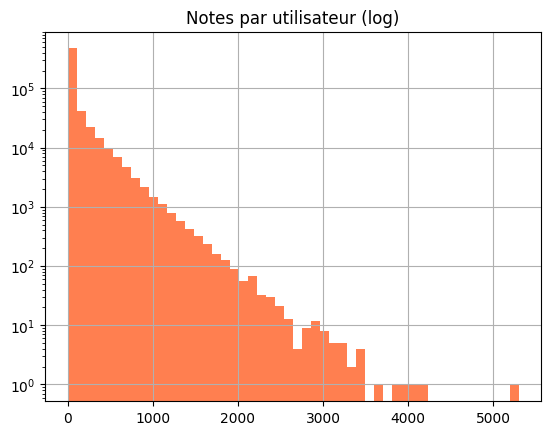

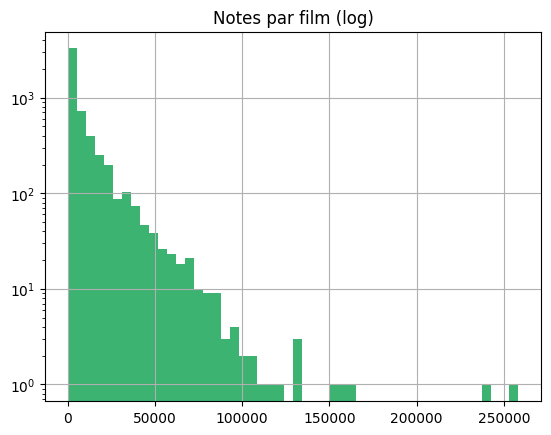

0.25      1.0
0.50      6.0
0.75     57.0
0.90    259.0
0.95    453.0
0.99    938.0
dtype: float64
0.25      668.00
0.50     3034.50
0.75    10336.25
0.90    24145.50
0.95    38302.00
0.99    71553.30
dtype: float64


In [5]:
# Distribution des notes
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue')
plt.title('Distribution des notes')
plt.show()

# Notes par utilisateur
notes_par_user = ratings.groupby('user_id').size()
notes_par_user.hist(bins=50, log=True, color='coral')
plt.title('Notes par utilisateur (log)')
plt.show()

# Notes par film
notes_par_film = ratings.groupby('film_id').size()
notes_par_film.hist(bins=50, log=True, color='mediumseagreen')
plt.title('Notes par film (log)')
plt.show()

print(notes_par_user.quantile([.25, .5, .75, .9, .95, .99]))
print(notes_par_film.quantile([.25, .5, .75, .9, .95, .99]))

In [6]:
seuils = [10, 20, 50, 100]

for s in seuils:
    users_gardes = ratings.groupby('user_id').size()[lambda x: x >= s]
    n_users = len(users_gardes)
    n_notes = users_gardes.sum()
    pct_users = n_users / ratings['user_id'].nunique() * 100
    pct_notes = n_notes / len(ratings) * 100
    print(f"seuil={s:4d} | users={n_users:7d} ({pct_users:.1f}%) | notes={n_notes:10d} ({pct_notes:.1f}%)")

seuil=  10 | users= 255214 (43.8%) | notes=  46686633 (98.2%)
seuil=  20 | users= 207157 (35.6%) | notes=  46026933 (96.8%)
seuil=  50 | users= 153469 (26.4%) | notes=  44305374 (93.2%)
seuil= 100 | users= 114315 (19.6%) | notes=  41489031 (87.2%)


On voit donc que le seuil de nombre de films minimum accepté devrait être 20: il retire beaucoup
d'utilisateurs sans impacter trop grandement le nombree de notes (on perd 3%)

In [7]:
avant = ratings.shape[0]
avant_users = ratings['user_id'].nunique()

MIN_USER_RATINGS = 20   # élimine les utilisateurs inutiles
MIN_FILM_RATINGS = 50   # quasi aucun film éliminé au vu de la médiane 
seed_user = ratings['user_id'].value_counts().index[0]

ratings = ratings[ratings['user_id'] != seed_user] #On élimine l'utilisateur qui est à l'origine de la liste
ratings = ratings[ratings['user_id'].map(ratings['user_id'].value_counts()) >= MIN_USER_RATINGS]
ratings = ratings[ratings['film_id'].map(ratings['film_id'].value_counts()) >= MIN_FILM_RATINGS]

sparsity = 1 - len(ratings) / (n_users * n_films)

print("Notes :", avant, "->", ratings.shape[0])
print("Users :", avant_users, "->", ratings['user_id'].nunique())
print("Films :", ratings['film_id'].nunique())
print("Sparsité du dataset : ", sparsity)

Notes : 47552698 -> 46015956
Users : 582329 -> 207156
Films : 5086
Sparsité du dataset :  0.9245621317408479


## On construit la matrice Sparse

In [8]:
#On encode les ID en indices pour faciliter la manipulation
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
film_encoder = LabelEncoder()

ratings["user_id"] = user_encoder.fit_transform(ratings["user_id"])
ratings["film_id"] = film_encoder.fit_transform(ratings["film_id"])

#Permet d'acceder au titre d'un film à partir de son ID
film_id_to_title = films.set_index("film_id")["title"].to_dict()


from scipy.sparse import csr_matrix

n_users = ratings["user_id"].nunique()
n_films = ratings["film_id"].nunique()

# On encode les notes comme "confiance" (plus la note est haute, plus c'est sûr)
sparse_matrix = csr_matrix(
    (ratings["rating"].values, ( ratings["film_id"].values, ratings["user_id"].values)),
    shape=(n_films, n_users)
)
